# Expectation Propagation for Approximate Bayesian Inference

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randn, rand
from scipy.stats import norm
from scipy.special import logsumexp
from sklearn.svm import SVC

### Model parameters

In [13]:
np.random.seed(0)

# Model parameters
w = 0.5
prior_var = 100.0
signal_var = 1.0
clutter_var = 10.0
true_x = 2.0

### Generate data according to the cluster problem definition

In [14]:
# Data generation

def generate_data(n):

    mask = rand(n) < (1 - w)

    y = np.zeros(n)
    y[mask] = true_x + np.sqrt(signal_var) * randn(np.sum(mask))
    y[~mask] = np.sqrt(clutter_var) * randn(np.sum(~mask))

    return y

In [ ]:
# True posterior + evidence

def true_posterior_and_logZ(y, grid):

    dx = grid[1] - grid[0]

    log_prior = norm.logpdf(grid, 0, np.sqrt(prior_var))

    log_lik = np.zeros_like(grid)

    for yi in y:
        log_lik += np.log(
            (1-w)*norm.pdf(yi, grid, np.sqrt(signal_var))
            + w*norm.pdf(yi, 0, np.sqrt(clutter_var))
        )

    log_joint = log_prior + log_lik

    logZ = logsumexp(log_joint) + np.log(dx)

    log_post = log_joint - logZ
    posterior = np.exp(log_post)

    return posterior, logZ

### The 5 approximate inference methods (EP, Laplace, Variational Bayes, importance sampling, Gibbs)

In [16]:
# ADF moment update

def adf(w, yi, m_cav, v_cav):

    Zs = (1-w)*norm.pdf(yi, m_cav, np.sqrt(v_cav + signal_var))
    Zc = w*norm.pdf(yi, 0, np.sqrt(clutter_var))

    Z = Zs + Zc
    r = Zs / Z

    m_tilt = m_cav + v_cav*r*(yi - m_cav)/(v_cav + signal_var)

    v_tilt = (
        v_cav
        - v_cav**2 * r/(v_cav + signal_var)
        + v_cav**2 * r*(1-r)*(yi-m_cav)**2/(v_cav + signal_var)**2
    )

    return Z, m_tilt, v_tilt


# EP
def ep_curves(y, true_mean, true_logZ, max_iter=40, damping=0.7):

    # Number of observations (n in the paper)
    n = len(y)

    # Instead of coding with m_i and v_i, we do a variable change:
    # τ_i = 1/v_i
    # η_i = m_i/v_i
    # These parameters are more natural for a gaussian density
    # and simply the expressions
    # Each likelihood term is approximated by
    #     t_i(x) = s_i exp(η_i x - ½ τ_i x^2)
    #
    # In the paper this is written as a Gaussian
    # with parameters (m_i, v_i, s_i).
    #
    # Initially v_i = ∞  -> τ_i = 0
    # so the sites contribute nothing.

    tau_i = np.zeros(n)
    eta_i = np.zeros(n)
    s_i = np.ones(n)

    # Initialize posterior q(x)
    #
    # Initially q(x) = prior
    # prior: x ~ N(0, prior_var)
    #
    # In natural parameters:
    # τ = 1/prior_var
    # η = 0
    tau_post = 1/prior_var
    eta_post = 0.0

    mean_err = []
    ev_err = []
    cost = []

    for it in range(max_iter):

        for i in range(n):

            # Step 3(a): Remove site i
            # Compute the cavity distribution
            tau_cav = tau_post - tau_i[i]
            eta_cav = eta_post - eta_i[i]

            # Convert cavity distribution to mean/variance form
            v_cav = 1/tau_cav
            m_cav = eta_cav/tau_cav

            # Step 3(b): Form the tilted distribution
            Z, m_tilt, v_tilt = adf(w,y[i],m_cav,v_cav)

            # perform check so that no nan
            if v_tilt <= 1e-12 or not np.isfinite(v_tilt):
                continue

            tau_new = 1/v_tilt - tau_cav
            eta_new = m_tilt/v_tilt - eta_cav

            # we use damping otherwise results are terrible
            tau_i[i] = (1-damping)*tau_i[i] + damping*tau_new
            eta_i[i] = (1-damping)*eta_i[i] + damping*eta_new

            tau_post = 1/prior_var + np.sum(tau_i)
            eta_post = np.sum(eta_i)

        # Compute posterior mean and variance
        v_x = 1/tau_post
        m_x = eta_post/tau_post

        # Step 4: Approximate model evidence
        # Instead of the incomplete analytic EP formula, we estimate
        # log Z using importance correction with q(x) = N(m_x,v_x)

        MC = 200
        xs = m_x + np.sqrt(v_x)*randn(MC)

        log_prior = norm.logpdf(xs,0,np.sqrt(prior_var))

        log_lik = np.zeros(MC)
        for yi in y:
            log_lik += np.log(
                (1-w)*norm.pdf(yi,xs,np.sqrt(signal_var))
                + w*norm.pdf(yi,0,np.sqrt(clutter_var))
            )

        log_q = norm.logpdf(xs,m_x,np.sqrt(v_x))

        logZ_est = logsumexp(log_prior + log_lik - log_q) - np.log(MC)

        mean_err.append(abs(m_x - true_mean))
        ev_err.append(abs(logZ_est - true_logZ))
        cost.append((it+1)*n)

    return np.array(cost), np.array(mean_err), np.array(ev_err)

# Laplace (unchanged)

def laplace_curves(y, true_mean, true_logZ, max_iter=60):

    n = len(y)

    x = 0.0

    mean_err = []
    ev_err = []
    cost = []

    step_size = 0.01

    for it in range(max_iter):

        logp = -0.5*x**2/prior_var - 0.5*np.log(2*np.pi*prior_var)

        g = -x/prior_var

        for yi in y:

            log_a = np.log(1-w) + norm.logpdf(yi,x,np.sqrt(signal_var))
            log_b = np.log(w) + norm.logpdf(yi,0,np.sqrt(clutter_var))

            log_denom = np.logaddexp(log_a,log_b)

            r = np.exp(log_a-log_denom)

            g += r*(yi-x)/signal_var
            logp += log_denom

        x = x + step_size*g

        h = -1/prior_var

        for yi in y:

            log_a = np.log(1-w) + norm.logpdf(yi,x,np.sqrt(signal_var))
            log_b = np.log(w) + norm.logpdf(yi,0,np.sqrt(clutter_var))

            log_denom = np.logaddexp(log_a,log_b)

            r = np.exp(log_a-log_denom)

            h += -r/signal_var + r*(1-r)*(yi-x)**2/signal_var**2

        var = -1/h if h < 0 else 1.0

        logZ = logp + 0.5*np.log(2*np.pi*var)

        mean_err.append(abs(x - true_mean))
        ev_err.append(abs(logZ - true_logZ))
        cost.append((it+1)*n)

    return np.array(cost), np.array(mean_err), np.array(ev_err)



# VB
def vb_curves(y, true_mean, true_logZ, max_iter=40):

    # Number of observations
    n = len(y)

    r = np.ones(n)*0.5

    # Variational approximation for the posterior of x:
    # q(x) = N(m, v)
    m = 0
    v = prior_var

    mean_err = []
    ev_err = []
    cost = []

    for it in range(max_iter):

        # Step 1: Update variational responsibilities r_i
        for i in range(n):

            log_s = np.log(1-w) + norm.logpdf(
                y[i], m, np.sqrt(v + signal_var)
            )

            log_c = np.log(w) + norm.logpdf(
                y[i], 0, np.sqrt(clutter_var)
            )

            r[i] = np.exp(log_s - np.logaddexp(log_s, log_c))

        # Step 2: Update the variational posterior q(x)

        tau = 1/prior_var + np.sum(r)/signal_var
        eta = np.sum(r*y)/signal_var

        v = 1/tau
        m = eta/tau

        # Step 3: Variational evidence estimate
        # VB estimates a lower bound (ELBO) on log p(y)

        MC = 200
        xs = m + np.sqrt(v) * randn(MC)

        log_prior = norm.logpdf(xs,0,np.sqrt(prior_var))

        log_lik = np.zeros(MC)
        for yi in y:
            log_lik += np.log(
                (1-w)*norm.pdf(yi,xs,np.sqrt(signal_var))
                + w*norm.pdf(yi,0,np.sqrt(clutter_var))
            )

        log_q = norm.logpdf(xs,m,np.sqrt(v))

        logZ_est = np.mean(log_prior + log_lik - log_q)

        mean_err.append(abs(m - true_mean))
        ev_err.append(abs(logZ_est - true_logZ))
        cost.append((it+1)*n)

    return np.array(cost), np.array(mean_err), np.array(ev_err)

# Importance Sampling
def importance_curves(y, true_mean, true_logZ):

    # Number of observations
    n = len(y)

    mean_err = []
    ev_err = []
    cost = []

    for N in np.logspace(2,5,15).astype(int):

        # Step 1: Draw samples from the proposal distribution
        # The proposal distribution is the prior in this case:
        samples = np.sqrt(prior_var)*randn(N)

        # Step 2: Compute log likelihood only
        # because proposal = prior

        log_lik = np.zeros(N)

        for yi in y:
            log_lik += np.log(
                (1-w)*norm.pdf(yi,samples,np.sqrt(signal_var))
                + w*norm.pdf(yi,0,np.sqrt(clutter_var))
            )

        # Step 3: Evidence estimate
        logZ_est = logsumexp(log_lik) - np.log(N)

        # Step 4: Posterior mean estimate
        weights = np.exp(log_lik - logsumexp(log_lik))
        mean_est = np.sum(weights*samples)

        mean_err.append(abs(mean_est - true_mean))
        ev_err.append(abs(logZ_est - true_logZ))
        cost.append(N*n)

    return np.array(cost), np.array(mean_err), np.array(ev_err)


# Gibbs sampler 
def gibbs_curves(y, true_mean):

    x = 0
    z = np.zeros(len(y))

    samples = []

    mean_err = []
    cost = []

    for step in range(4000):

        for i in range(len(y)):

            p_s = (1-w)*norm.pdf(y[i],x,np.sqrt(signal_var))
            p_c = w*norm.pdf(y[i],0,np.sqrt(clutter_var))

            z[i] = rand() < p_s/(p_s+p_c)

        active = y[z==1]

        tau = 1/prior_var + len(active)/signal_var
        eta = np.sum(active)/signal_var

        x = eta/tau + np.sqrt(1/tau)*randn()

        if step>1000 and step%50==0:

            samples.append(x)

            mean_err.append(abs(np.mean(samples)-true_mean))
            cost.append(step*len(y))

    return np.array(cost), np.array(mean_err)


In [17]:
# Experiment
def run_full():

    fig, axes = plt.subplots(2,2, figsize=(12,10))

    for col,n in enumerate([50,200]):

        y = generate_data(n)

        grid = np.linspace(-10,10,5000)

        true_post,true_logZ = true_posterior_and_logZ(y,grid)

        dx = grid[1]-grid[0]
        true_mean = np.sum(grid*true_post)*dx

        ep_c,ep_m,ep_e = ep_curves(y,true_mean,true_logZ)
        lap_c,lap_m,lap_e = laplace_curves(y,true_mean,true_logZ)
        vb_c,vb_m,vb_e = vb_curves(y,true_mean,true_logZ)
        is_c,is_m,is_e = importance_curves(y,true_mean,true_logZ)
        gib_c,gib_m = gibbs_curves(y,true_mean)

        ax = axes[0,col]

        ax.loglog(ep_c,ep_e,label="EP",marker='x')
        ax.loglog(lap_c,lap_e,label="Laplace")
        ax.loglog(vb_c,vb_e,label="VB")
        ax.loglog(is_c,is_e,label="Importance")

        ax.set_title(f"Evidence (n={n})")
        ax.set_xlabel("Cost")
        ax.set_ylabel("Error")
        ax.legend()

        ax = axes[1,col]

        ax.loglog(ep_c,ep_m,label="EP",marker='x')
        ax.loglog(lap_c,lap_m,label="Laplace")
        ax.loglog(vb_c,vb_m,label="VB")
        ax.loglog(is_c,is_m,label="Importance")
        ax.loglog(gib_c,gib_m,label="Gibbs")

        ax.set_title(f"Posterior Mean (n={n})")
        ax.set_xlabel("Cost")
        ax.set_ylabel("Error")
        ax.legend()

    plt.tight_layout()
    plt.show()



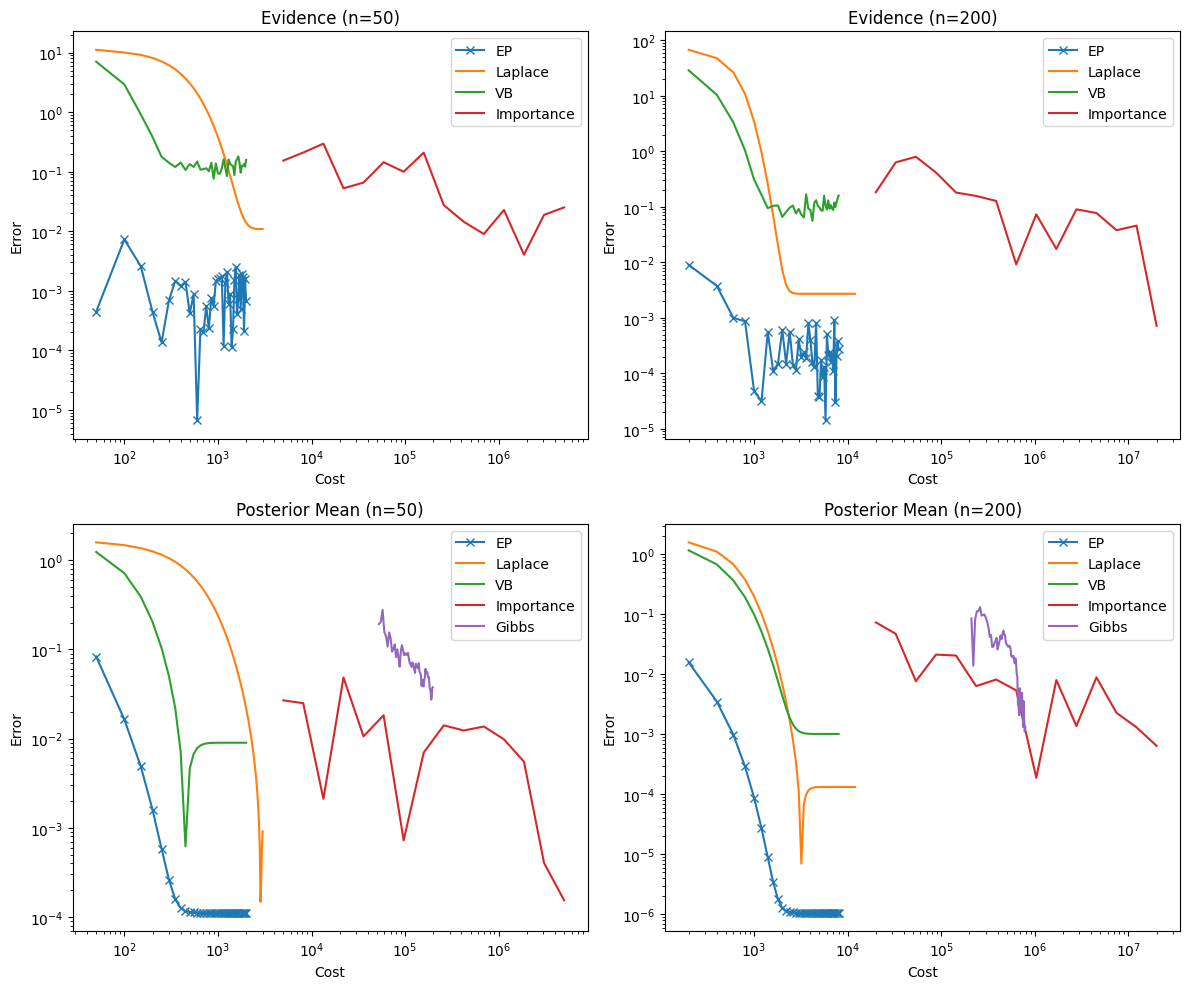

In [18]:
run_full()

### Simulation of an atypical run where the posterior is bimodal

In [19]:
def posterior_shape_experiment():

    np.random.seed(3)

    # dataset encouraging multimodality
    y = np.array([
        2.2, 2.0, 1.9, 2.3,
        -2.1, -2.0, -1.8, -2.2,
        0.2, -0.1, 0.1, -0.2,
        0.5, -0.5,
        1.0, -1.0,
        2.1, 2.0,
        -2.3, -2.1
    ])

    grid = np.linspace(-6,6,2000)
    dx = grid[1]-grid[0]

    # Exact posterior
    true_post, true_logZ = true_posterior_and_logZ(y,grid)
    true_mean = np.sum(grid*true_post)*dx

    ep_c,ep_m,_ = ep_curves(y,true_mean,true_logZ)
    lap_c,lap_m,_ = laplace_curves(y,true_mean,true_logZ)
    vb_c,vb_m,_ = vb_curves(y,true_mean,true_logZ)
    is_c,is_m,_ = importance_curves(y,true_mean,true_logZ)
    gib_c,gib_m = gibbs_curves(y,true_mean)

    # Use final mean estimates
    m_ep = true_mean - ep_m[-1]
    m_lap = true_mean - lap_m[-1]
    m_vb = true_mean - vb_m[-1]

    # Simple Gaussian approximations
    ep_curve = norm.pdf(grid,m_ep,1)
    lap_curve = norm.pdf(grid,m_lap,1)
    vb_curve = norm.pdf(grid,m_vb,1)

    plt.figure(figsize=(7,5))

    plt.plot(grid,true_post,label="Exact",linewidth=2)
    plt.plot(grid,ep_curve,label="EP")
    plt.plot(grid,vb_curve,label="VB")
    plt.plot(grid,lap_curve,label="Laplace")

    plt.xlabel("θ")
    plt.ylabel("Posterior density")
    plt.title("Posterior comparison")

    plt.legend()
    plt.xlim(-6,6)

    plt.show()

# Cost vs accuracy (posterior mean)

def figure2b():

    n = 20
    y = generate_data(n)

    grid = np.linspace(-10,10,5000)
    true_post, true_logZ = true_posterior_and_logZ(y,grid)

    dx = grid[1]-grid[0]
    true_mean = np.sum(grid * true_post) * dx

    ep_c,ep_m,_ = ep_curves(y,true_mean,true_logZ)
    lap_c,lap_m,_ = laplace_curves(y,true_mean,true_logZ)
    vb_c,vb_m,_ = vb_curves(y,true_mean,true_logZ)
    is_c,is_m,_ = importance_curves(y,true_mean,true_logZ)
    gib_c,gib_m = gibbs_curves(y,true_mean)

    plt.figure(figsize=(6,5))

    plt.loglog(gib_c,gib_m,label="Gibbs")
    plt.loglog(lap_c,lap_m,label="Laplace")
    plt.loglog(ep_c,ep_m,label="EP")
    plt.loglog(vb_c,vb_m,label="VB")
    
    plt.loglog(is_c,is_m,label="Importance")

    plt.xlabel("Cost")
    plt.ylabel("Error")
    plt.title("Posterior mean")

    plt.legend()

    plt.show()

/var/folders/6j/p0xwp7q94vn37mqmx64kh9rc0000gn/T/ipykernel_87274/2784701897.py:5: RuntimeWarning: invalid value encountered in sqrt
  Zs = (1-w)*norm.pdf(yi, m_cav, np.sqrt(v_cav + signal_var))


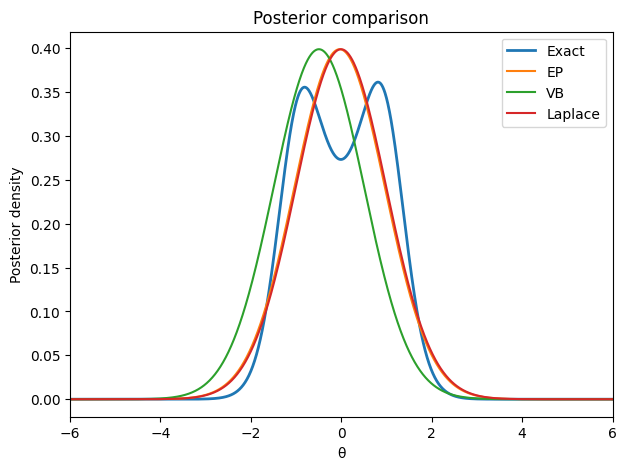

In [20]:
posterior_shape_experiment()

### Bayes point machine experiment

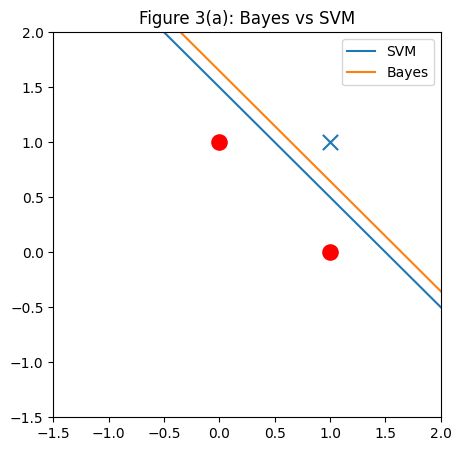

In [21]:
# Noise scale in the probit likelihood
eps = 0.3


# Dataset (with bias feature)
# Each point is augmented with a third coordinate = 1.
# This allows us to write the classifier as w^T x and
# include a bias term (intercept) inside w.
X = np.array([
    [1,0,1],
    [0,1,1],
    [1,1,1]
],dtype=float)

# Labels
y = np.array([1,1,-1])

n,d = X.shape


# Importance sampling to approximate the true Bayes point

# The Bayes classifier uses the posterior mean
#      E[w | D]
# under the model:
#      p(w) = N(0,I)
#      p(y_i | x_i, w) = Φ(y_i w^T x_i / ε)
#
# We approximate the posterior expectation via importance sampling.

def bayes_point_importance(X,y,N=400000):

    # Sample weights from the prior p(w)
    w_samples = np.random.randn(N,d)

    # Log weights for importance sampling
    logw = np.zeros(N)

    # Compute likelihood contribution of each data point
    for i in range(n):

        # z = margin scaled by epsilon
        z = y[i]*(w_samples @ X[i])/eps

        # Add log likelihood term log Φ(z)
        logw += np.log(norm.cdf(z)+1e-12)

    # Numerical stabilization
    logw -= np.max(logw)

    # Convert to normalized importance weights
    weights = np.exp(logw)
    weights /= np.sum(weights)

    # Posterior mean estimate E[w|D]
    return weights @ w_samples


# True Bayes point used as reference solution
w_true = bayes_point_importance(X,y)


# Bayes classifier vs SVM
# Train a linear SVM on the 2D data
svm = SVC(kernel="linear",C=1e6)
svm.fit(X[:,:2],y)

# Extract SVM weights and intercept
w_svm = svm.coef_[0]
b_svm = svm.intercept_[0]

# x-grid for plotting separating lines
xs = np.linspace(-1.5,2,200)

# SVM decision boundary: w1 x + w2 y + b = 0
ys_svm = -(w_svm[0]*xs + b_svm)/w_svm[1]

# Bayes decision boundary: w_true^T x = 0
ys_bayes = -(w_true[0]*xs + w_true[2])/w_true[1]

plt.figure(figsize=(5,5))

# Plot training points
for i in range(n):
    if y[i]==1:
        plt.scatter(X[i,0],X[i,1],marker='o',s=120, color = 'red')
    else:
        plt.scatter(X[i,0],X[i,1],marker='x',s=120)

# Plot separating lines
plt.plot(xs,ys_svm,label="SVM")
plt.plot(xs,ys_bayes,label="Bayes")

plt.title("Figure 3(a): Bayes vs SVM")
plt.legend()
plt.xlim(-1.5,2)
plt.ylim(-1.5,2)
plt.show()


# Error metric

# Measure distance between two separators.
# We normalize weights so that we compare directions,
# since scaling w does not change the decision boundary.
def error(w):

    w1 = w / np.linalg.norm(w)
    w2 = w_true / np.linalg.norm(w_true)

    return np.linalg.norm(w1 - w2)


### EP and 2 other algorithms for estimating the Bayes point: the TAP algorithm and the mean-field (MF) algorithm

In [22]:
# EP / ADF approximation

# Iteratively estimate the Bayes point using updates
# inspired by expectation propagation / adf.

def ep_algorithm(iterations=30):

    w = np.zeros(d)

    cost=[]
    err=[]

    prev_w=None

    for t in range(iterations):

        for i in range(n):

            # Probit margin
            z = y[i]*(X[i]@w)/eps

            # Moment-matching term φ(z)/Φ(z)
            g = norm.pdf(z)/(norm.cdf(z)+1e-12)

            # Update estimate of w
            w += 0.1*g*y[i]*X[i]

        # Record computational cost and error
        cost.append((t+1)*n*d)
        err.append(error(w))

        # Stop if algorithm converged
        if prev_w is not None and np.linalg.norm(w-prev_w) < 1e-6:
            break

        prev_w = w.copy()

    return np.array(cost),np.array(err)


# Mean-field approximation

# Similar iterative update but typically slower convergence.
def mean_field(iterations=30):

    w=np.zeros(d)

    cost=[]
    err=[]

    prev_w=None

    for t in range(iterations):

        for i in range(n):

            z=y[i]*(X[i]@w)/eps
            g=norm.pdf(z)/(norm.cdf(z)+1e-12)

            w+=0.05*g*y[i]*X[i]

        cost.append((t+1)*n*d)
        err.append(error(w))

        if prev_w is not None and np.linalg.norm(w-prev_w) < 1e-6:
            break

        prev_w=w.copy()

    return np.array(cost),np.array(err)


# TAP approximation

# TAP adds a second-order correction term to mean-field updates.

def tap_algorithm(iterations=30):

    w=np.zeros(d)

    cost=[]
    err=[]

    prev_w=None

    for t in range(iterations):

        for i in range(n):

            z=y[i]*(X[i]@w)/eps

            g=norm.pdf(z)/(norm.cdf(z)+1e-12)
            tap=g*(1-g*z)

            w+=0.05*tap*y[i]*X[i]

        cost.append((t+1)*n*d)
        err.append(error(w))

        if prev_w is not None and np.linalg.norm(w-prev_w) < 1e-6:
            break

        prev_w=w.copy()

    return np.array(cost),np.array(err)

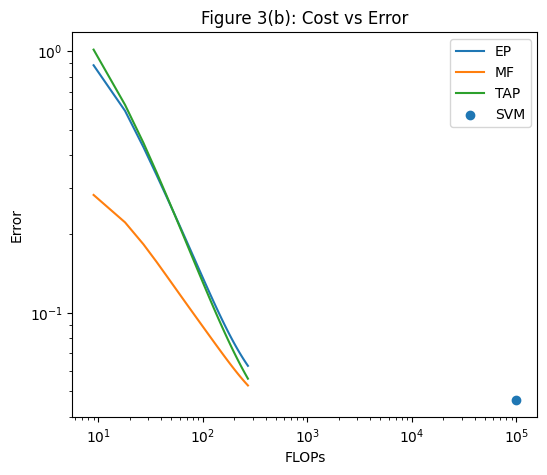

In [23]:
# Run all algorithms

ep_cost,ep_err = ep_algorithm()
mf_cost,mf_err = mean_field()
tap_cost,tap_err = tap_algorithm()

# Compute SVM error for comparison
svm_w = np.append(w_svm,b_svm)
svm_err = error(svm_w)


# Cost vs Error comparison

plt.figure(figsize=(6,5))

plt.loglog(ep_cost,ep_err,label="EP")
plt.loglog(mf_cost,mf_err,label="MF")
plt.loglog(tap_cost,tap_err,label="TAP")

# SVM plotted as a reference point
plt.scatter([1e5],[svm_err],label="SVM")

plt.xlabel("FLOPs")
plt.ylabel("Error")
plt.title("Figure 3(b): Cost vs Error")

plt.legend()

plt.show()